# Notebook 9: Seaborn — Statistical Data Visualisation
### ML Skills Refresh Curriculum — Module 9 of 30
#### Module 3: Data Visualisation Masterclass — Notebook 2 of 3

---

## 🎯 Learning Objectives

| # | Topic | Why It Matters in ML |
|---|-------|----------------------|
| 1 | Matplotlib vs Seaborn relationship | Knowing the layers lets you customise Seaborn output with Matplotlib calls |
| 2 | Box plot — quartiles & outliers explained | The primary tool for spotting outliers before feature scaling |
| 3 | Correlation matrix — the math explained | Reveals multicollinearity before regression; guides feature selection |
| 4 | `sns.heatmap` — visualising the correlation matrix | Makes a table of 20+ correlation numbers scannable in seconds |
| 5 | `sns.pairplot` — all pairwise relationships at once | The single most efficient EDA plot for a new multi-feature dataset |
| 6 | `sns.violinplot` — distribution shape by category | Richer than a box plot — shows the full distribution, not just five summary numbers |
| 7 | Seaborn themes and palettes | Consistent aesthetics across an entire ML report |

---

> **Dataset Context:** A synthetic **Cardiovascular Health dataset** — 200 patients, each with `age`, `bmi`, `blood_pressure`, `cholesterol`, `glucose`, `exercise_hours` (per week), and a categorical `risk_category` (`Low`, `Medium`, `High`). The numeric features are deliberately correlated (e.g. BMI drives blood pressure; age drives cholesterol) so the heatmap and pairplot produce genuinely informative patterns.

---
## Section 1 — Matplotlib and Seaborn: The Relationship

### 📖 The Logic — Before Any Code

**Seaborn is a high-level wrapper built on top of Matplotlib.** Every Seaborn function ultimately creates Matplotlib `Figure` and `Axes` objects under the hood — it just does so with far less code and much better default aesthetics.

```
┌──────────────────────────────────────────────────────┐
│                    Your code                         │
├──────────────────────────────────────────────────────┤
│          Seaborn  (high-level statistical API)       │
│   sns.boxplot()  sns.heatmap()  sns.pairplot()       │
├──────────────────────────────────────────────────────┤
│      Matplotlib  (low-level drawing engine)          │
│   Figure / Axes / Lines / Patches / Collections      │
├──────────────────────────────────────────────────────┤
│          NumPy  (array backbone)                     │
└──────────────────────────────────────────────────────┘
```

**The practical consequence:** a Seaborn plot IS a Matplotlib plot. After calling `sns.boxplot(ax=ax)`, you can immediately call `ax.set_title()`, `ax.set_xlabel()`, `ax.spines["top"].set_visible(False)` — every Matplotlib customisation method works exactly as in Notebook 8.

**When to use which:**

| Task | Prefer |
|------|--------|
| Line plots, bar charts, basic scatter | Matplotlib — more control |
| Statistical summaries (box, violin, distribution) | Seaborn — built-in stats |
| Correlation heatmaps, pair plots | Seaborn — DataFrame-aware, automatic |
| Fine-grained layout (GridSpec, twin axes) | Matplotlib — Seaborn can't do this |
| Publication polish on a Seaborn plot | Seaborn first, then Matplotlib to tweak |

---

### Two Seaborn Plot Patterns

Seaborn functions come in two flavours, and knowing which you have determines how you customise them:

| Flavour | Examples | Returns | How to customise |
|---------|---------|---------|------------------|
| **Axes-level** | `sns.boxplot`, `sns.violinplot`, `sns.heatmap` | A Matplotlib `Axes` | Pass `ax=ax`; then call `ax.set_*()` methods |
| **Figure-level** | `sns.pairplot`, `sns.FacetGrid` | A Seaborn `PairGrid` / `FacetGrid` object | Access `.fig` attribute for the Figure; `.axes` for the grid of Axes |

In [1]:
import seaborn as sns                   # high-level statistical plotting
import matplotlib.pyplot as plt         # low-level customisation
import matplotlib.gridspec as gridspec  # fine-grained subplot layout
import numpy as np                      # numeric operations
import pandas as pd                     # DataFrame creation and handling

# ── Set Seaborn theme ─────────────────────────────────────────────────────────
# sns.set_theme() configures both Seaborn AND Matplotlib defaults globally
sns.set_theme(
    style="whitegrid",    # background style: whitegrid / darkgrid / white / dark / ticks
    palette="muted",      # default colour palette for categorical variables
    font_scale=1.05       # scale all font sizes up slightly
)

plt.rcParams["figure.dpi"] = 110   # crisp output in Jupyter
np.random.seed(42)                 # reproducible data generation

print(f"Seaborn    version: {sns.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

Seaborn    version: 0.13.2
Matplotlib version: 3.10.0


---
## Section 2 — Building the Cardiovascular Health Dataset

In [2]:
n = 200   # number of patients

# ── Age: uniformly distributed 30–75 years ───────────────────────────────────
age = np.random.uniform(30, 75, n)

# ── BMI: normally distributed around 27 (slightly overweight average) ────────
bmi = np.random.normal(27, 5, n)
bmi = np.clip(bmi, 16, 45)   # clamp to realistic physiological range

# ── Blood pressure: driven by both age and BMI, plus noise ───────────────────
# Higher age and higher BMI both independently raise blood pressure
blood_pressure = (
    90                             # baseline systolic BP
    + 0.55 * age                   # age contribution
    + 1.20 * bmi                   # BMI contribution
    + np.random.normal(0, 8, n)    # individual variation
)
blood_pressure = np.clip(blood_pressure, 80, 200)

# ── Cholesterol: driven by age and BMI ───────────────────────────────────────
cholesterol = (
    130
    + 1.10 * age
    + 2.50 * bmi
    + np.random.normal(0, 20, n)
)
cholesterol = np.clip(cholesterol, 120, 320)

# ── Glucose: mildly correlated with BMI ──────────────────────────────────────
glucose = (
    70
    + 1.80 * bmi
    + np.random.normal(0, 12, n)
)
glucose = np.clip(glucose, 60, 200)

# ── Exercise hours per week: inversely correlated with BMI and BP ─────────────
exercise_hours = (
    12
    - 0.20 * bmi
    - 0.05 * blood_pressure
    + np.random.normal(0, 2, n)
)
exercise_hours = np.clip(exercise_hours, 0, 20).round(1)

# ── Risk category: derived from blood pressure and cholesterol thresholds ─────
# Low: BP < 130 AND cholesterol < 200
# High: BP >= 150 OR  cholesterol >= 250
# Medium: everything else
risk = []
for bp, chol in zip(blood_pressure, cholesterol):
    if bp >= 150 or chol >= 250:
        risk.append("High")
    elif bp < 130 and chol < 200:
        risk.append("Low")
    else:
        risk.append("Medium")

# ── Assemble DataFrame ────────────────────────────────────────────────────────
df = pd.DataFrame({
    "age"             : age.round(1),
    "bmi"             : bmi.round(1),
    "blood_pressure"  : blood_pressure.round(1),
    "cholesterol"     : cholesterol.round(1),
    "glucose"         : glucose.round(1),
    "exercise_hours"  : exercise_hours,
    "risk_category"   : pd.Categorical(
                            risk,
                            categories=["Low", "Medium", "High"],
                            ordered=True          # ordered so plots sort correctly
                        )
})

print(f"Shape: {df.shape}")
print()
print("── Head ──")
print(df.head(8).to_string())
print("\n── Risk category counts ──")
print(df["risk_category"].value_counts().sort_index())

Shape: (200, 7)

── Head ──
    age   bmi  blood_pressure  cholesterol  glucose  exercise_hours risk_category
0  46.9  23.6           151.0        263.9    100.8             0.0          High
1  72.8  28.2           162.5        285.6    133.3             1.1          High
2  62.9  28.5           158.6        277.1    109.8             0.0          High
3  56.9  23.4           141.4        243.0    143.8             2.5        Medium
4  37.0  36.3           153.8        251.8    141.3             0.0          High
5  37.0  29.4           143.3        235.5    125.1             0.0        Medium
6  32.6  21.0           135.8        226.4     97.6             2.1        Medium
7  69.0  30.3           157.7        273.2    132.9             0.0          High

── Risk category counts ──
risk_category
Low         3
Medium     56
High      141
Name: count, dtype: int64


In [3]:
# ── Quick numeric summary ─────────────────────────────────────────────────────
print("── Descriptive Statistics ──")
print(df.describe().round(2).to_string())

── Descriptive Statistics ──
          age     bmi  blood_pressure  cholesterol  glucose  exercise_hours
count  200.00  200.00          200.00       200.00   200.00          200.00
mean    51.78   27.36          150.85       254.74   121.33            0.61
std     13.27    4.75           12.15        26.98    14.00            1.11
min     30.20   16.00          122.80       193.60    85.00            0.00
25%     40.30   23.68          142.90       237.73   111.20            0.00
50%     52.25   27.45          150.15       253.65   122.05            0.00
75%     64.05   30.32          159.72       271.05   130.30            0.70
max     74.40   45.00          184.20       317.60   159.70            5.40


---
## Section 3 — Box Plot: The Maths Before the Code

### 📖 The Logic

A **box plot** (also called a box-and-whisker plot) condenses an entire distribution into five summary numbers, called the **five-number summary**. Understanding what each element represents is essential for interpreting the plot correctly.

```
                          ┌─────────────────┐
   lower   Q1             │                 │   Q3   upper
  whisker  ├──────────────┤      MEDIAN     ├──────────────┤  whisker
    ──●    │              │       (Q2)      │              │    ──●
           └─────────────┬┘                 └┬─────────────┘
                         │◄──── IQR ────────►│

  ○  ○                                                     ○   ← outliers
```

| Element | What it is | Formula |
|---------|-----------|------|
| **Q1** (bottom of box) | 25th percentile — 25% of values fall below this | `np.percentile(data, 25)` |
| **Median / Q2** (line in box) | 50th percentile — the middle value | `np.median(data)` |
| **Q3** (top of box) | 75th percentile — 75% of values fall below this | `np.percentile(data, 75)` |
| **IQR** (box height) | Interquartile range — contains the middle 50% of data | `Q3 - Q1` |
| **Lower whisker** | Lowest value still within `Q1 - 1.5 × IQR` | Data-driven, not fixed |
| **Upper whisker** | Highest value still within `Q3 + 1.5 × IQR` | Data-driven, not fixed |
| **Outliers** (dots) | Individual points beyond the whiskers | `< Q1 - 1.5×IQR` or `> Q3 + 1.5×IQR` |

**Why the `1.5 × IQR` rule?** For a perfect normal distribution, points beyond `Q1 - 1.5×IQR` and `Q3 + 1.5×IQR` account for only ~0.7% of the data. So in practice, any plotted dot is a genuinely unusual value worth investigating.

**In ML:** before fitting a StandardScaler or RobustScaler, you inspect box plots to understand outlier severity. Before training a K-Nearest Neighbours model, you check whether the whiskers are symmetric (if not, the feature may need a log transform).

In [4]:
# ── Manually compute the five-number summary for blood_pressure ───────────────
# This verifies that our understanding of the box plot elements matches the data

bp = df["blood_pressure"].values

Q1  = np.percentile(bp, 25)         # 25th percentile
Q2  = np.percentile(bp, 50)         # median / 50th percentile
Q3  = np.percentile(bp, 75)         # 75th percentile
IQR = Q3 - Q1                       # interquartile range

lower_fence = Q1 - 1.5 * IQR        # lower whisker boundary
upper_fence = Q3 + 1.5 * IQR        # upper whisker boundary

# Whisker endpoints are the most extreme DATA POINTS still within the fences
lower_whisker = bp[bp >= lower_fence].min()   # smallest non-outlier
upper_whisker = bp[bp <= upper_fence].max()   # largest non-outlier

outliers = bp[(bp < lower_fence) | (bp > upper_fence)]  # points outside fences

print("── Five-Number Summary: blood_pressure ──")
print(f"  Q1 (25th pct)    : {Q1:.1f}")
print(f"  Q2 / Median      : {Q2:.1f}")
print(f"  Q3 (75th pct)    : {Q3:.1f}")
print(f"  IQR              : {IQR:.1f}")
print(f"  Lower fence      : {lower_fence:.1f}")
print(f"  Upper fence      : {upper_fence:.1f}")
print(f"  Lower whisker    : {lower_whisker:.1f}  (lowest non-outlier)")
print(f"  Upper whisker    : {upper_whisker:.1f}  (highest non-outlier)")
print(f"  Outlier count    : {len(outliers)}")
if len(outliers) > 0:
    print(f"  Outlier values   : {sorted(outliers.round(1))}")

── Five-Number Summary: blood_pressure ──
  Q1 (25th pct)    : 142.9
  Q2 / Median      : 150.1
  Q3 (75th pct)    : 159.7
  IQR              : 16.8
  Lower fence      : 117.7
  Upper fence      : 185.0
  Lower whisker    : 122.8  (lowest non-outlier)
  Upper whisker    : 184.2  (highest non-outlier)
  Outlier count    : 0


/tmp/ipykernel_10588/2947025135.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


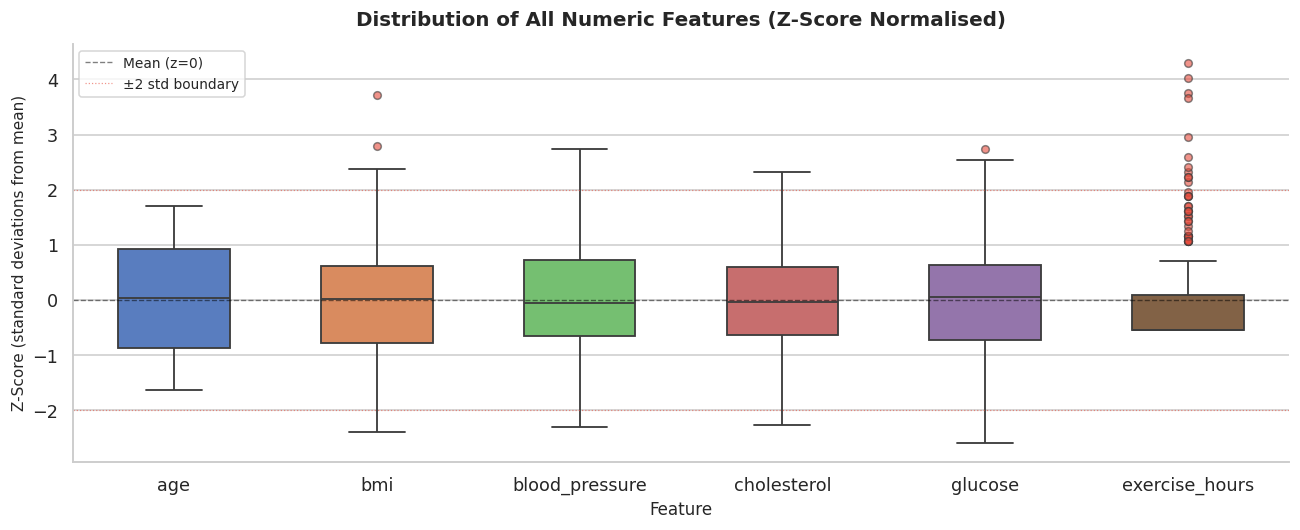


📊 Reading the chart:
  All boxes are centred near z=0 by construction. The IQR (box height)
  and whisker length vary by feature — taller boxes = more spread.
  Red dots beyond the whiskers are outliers by the 1.5×IQR rule.
  BMI and exercise_hours show the most visible outliers in this dataset.



In [5]:
# ── Box plot — all numeric features side by side ──────────────────────────────
# We normalise (z-score) the data so all features fit on one y-axis scale

numeric_cols = ["age", "bmi", "blood_pressure", "cholesterol", "glucose", "exercise_hours"]

# Compute z-scores: subtract column mean, divide by column std
df_z = df[numeric_cols].apply(lambda col: (col - col.mean()) / col.std())

# Melt from wide format to long format — Seaborn prefers 'tidy' data
# pd.melt() turns each column into a (variable, value) row pair
df_z_long = df_z.melt(var_name="Feature", value_name="Z-Score")

fig, ax = plt.subplots(figsize=(12, 5))

sns.boxplot(
    data     = df_z_long,          # tidy DataFrame
    x        = "Feature",          # categorical column → x-axis groups
    y        = "Z-Score",          # numeric column → y-axis values
    palette  = "muted",            # Seaborn colour palette
    width    = 0.55,               # box width (0–1)
    linewidth= 1.2,                # border line thickness
    flierprops = dict(             # style for outlier dots
        marker="o",
        markerfacecolor="#e74c3c",
        markersize=5,
        alpha=0.6
    ),
    ax = ax                        # draw into our explicit Axes
)

# ── Matplotlib customisation on top of the Seaborn plot ──────────────────────
ax.axhline(0,  color="black",   linewidth=0.9, linestyle="--", alpha=0.5,
           label="Mean (z=0)")
ax.axhline(2,  color="#e74c3c", linewidth=0.8, linestyle=":",  alpha=0.6,
           label="±2 std boundary")
ax.axhline(-2, color="#e74c3c", linewidth=0.8, linestyle=":",  alpha=0.6)

ax.set_title("Distribution of All Numeric Features (Z-Score Normalised)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Feature", fontsize=11)
ax.set_ylabel("Z-Score (standard deviations from mean)", fontsize=10)
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()

print("""
📊 Reading the chart:
  All boxes are centred near z=0 by construction. The IQR (box height)
  and whisker length vary by feature — taller boxes = more spread.
  Red dots beyond the whiskers are outliers by the 1.5×IQR rule.
  BMI and exercise_hours show the most visible outliers in this dataset.
""")

/tmp/ipykernel_10588/1866906034.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_10588/1866906034.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_10588/1866906034.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


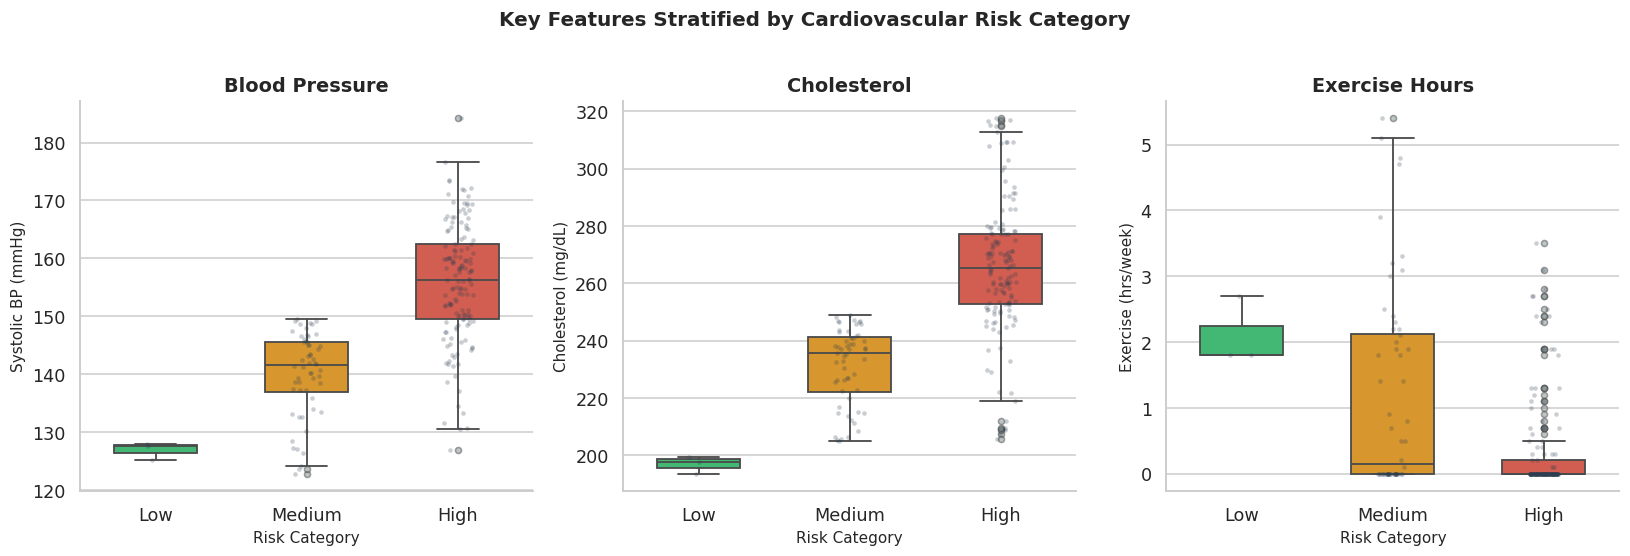


📊 Reading the chart:
  Blood Pressure and Cholesterol both rise clearly from Low → Medium → High risk,
  confirming they drive the risk labels in our synthetic data.
  Exercise Hours shows the reverse — High-risk patients exercise the least.
  The dark semi-transparent dots reveal the underlying data density inside each box.



In [6]:
# ── Box plot grouped by risk category — most useful EDA pattern ───────────────
# Answers: "Does blood pressure differ significantly across risk groups?"

# Define a consistent colour palette keyed to the three risk levels
risk_palette = {"Low": "#2ecc71", "Medium": "#f39c12", "High": "#e74c3c"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Key Features Stratified by Cardiovascular Risk Category",
             fontsize=13, fontweight="bold", y=1.01)

features_to_plot = ["blood_pressure", "cholesterol", "exercise_hours"]
ylabels          = ["Systolic BP (mmHg)", "Cholesterol (mg/dL)", "Exercise (hrs/week)"]

for ax, feature, ylabel in zip(axes, features_to_plot, ylabels):

    sns.boxplot(
        data     = df,
        x        = "risk_category",    # group by risk level on x-axis
        y        = feature,             # show this feature on y-axis
        order    = ["Low","Medium","High"],  # enforce order (Categorical is ordered but explicit is safer)
        palette  = risk_palette,        # colour-code each risk group
        width    = 0.55,
        linewidth= 1.2,
        flierprops = dict(marker="o", markerfacecolor="#7f8c8d",
                          markersize=4, alpha=0.5),
        ax = ax
    )

    # Overlay raw data as a strip plot so individual points are visible
    # strip plots sit on top of box plots and show the actual data density
    sns.stripplot(
        data    = df,
        x       = "risk_category",
        y       = feature,
        order   = ["Low","Medium","High"],
        color   = "#2c3e50",
        size    = 3,
        alpha   = 0.25,        # very transparent so boxes remain visible
        jitter  = True,        # scatter points horizontally to reduce overplotting
        ax      = ax
    )

    ax.set_title(feature.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel("Risk Category", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()

print("""
📊 Reading the chart:
  Blood Pressure and Cholesterol both rise clearly from Low → Medium → High risk,
  confirming they drive the risk labels in our synthetic data.
  Exercise Hours shows the reverse — High-risk patients exercise the least.
  The dark semi-transparent dots reveal the underlying data density inside each box.
""")

---
## Section 4 — Correlation Matrix: The Maths Before the Heatmap

### 📖 The Logic

A **correlation matrix** is a square table where every cell `[i, j]` contains the **Pearson correlation coefficient** between feature `i` and feature `j`.

#### What is the Pearson correlation coefficient?

For two features X and Y, the Pearson coefficient **r** measures the strength and direction of their **linear relationship**:

```
         Σ( (xᵢ - x̄)(yᵢ - ȳ) )
r  =  ─────────────────────────────────────
       √[ Σ(xᵢ-x̄)² ] × √[ Σ(yᵢ-ȳ)² ]

  Numerator   = sum of the product of deviations from each mean
  Denominator = product of each variable's standard deviation × n
```

**The key values to know:**

| r value | Interpretation |
|---------|----------------|
| `+1.0` | Perfect positive linear relationship — as X increases, Y increases exactly proportionally |
| `+0.7 to +1.0` | Strong positive correlation |
| `+0.3 to +0.7` | Moderate positive correlation |
| `-0.3 to +0.3` | Weak or no linear relationship |
| `-0.7 to -0.3` | Moderate negative correlation |
| `-1.0 to -0.7` | Strong negative correlation |
| `-1.0` | Perfect negative linear relationship |

**The diagonal is always 1.0** — a variable is perfectly correlated with itself.

**The matrix is symmetric** — `r(X, Y) == r(Y, X)`, so the upper and lower triangles are mirror images.

#### Why this matters in ML

| ML concern | How the correlation matrix reveals it |
|-----------|---------------------------------------|
| **Multicollinearity** | Two features with `|r| > 0.85` carry almost the same information — one can often be dropped |
| **Redundant features** | High cross-correlation between predictors → unstable regression coefficients |
| **Feature-target relationship** | The column for the target variable shows which features are most predictive |
| **Feature selection guidance** | Keep features with high `|r|` to the target, low `|r|` to other features |

In [7]:
# ── Compute and inspect the correlation matrix ────────────────────────────────
# df.corr() computes pairwise Pearson r for all numeric columns
corr_matrix = df[numeric_cols].corr().round(3)   # rounded to 3 dp for readability

print("── Pearson Correlation Matrix ──")
print(corr_matrix.to_string())

# ── Manually verify one cell ──────────────────────────────────────────────────
# r(age, cholesterol) — computed from scratch using NumPy
x_val = df["age"].values
y_val = df["cholesterol"].values

r_manual = (
    np.sum((x_val - x_val.mean()) * (y_val - y_val.mean()))  # numerator
    / (
        np.sqrt(np.sum((x_val - x_val.mean()) ** 2))         # denominator left
        * np.sqrt(np.sum((y_val - y_val.mean()) ** 2))        # denominator right
    )
)
r_pandas = corr_matrix.loc["age", "cholesterol"]

print(f"\nManual r(age, cholesterol)  : {r_manual:.4f}")
print(f"Pandas r(age, cholesterol)  : {r_pandas:.4f}   ← matches ✓")

── Pearson Correlation Matrix ──
                  age    bmi  blood_pressure  cholesterol  glucose  exercise_hours
age             1.000 -0.027           0.621        0.542    0.054          -0.169
bmi            -0.027  1.000           0.406        0.368    0.589          -0.388
blood_pressure  0.621  0.406           1.000        0.547    0.275          -0.393
cholesterol     0.542  0.368           0.547        1.000    0.339          -0.243
glucose         0.054  0.589           0.275        0.339    1.000          -0.180
exercise_hours -0.169 -0.388          -0.393       -0.243   -0.180           1.000

Manual r(age, cholesterol)  : 0.5421
Pandas r(age, cholesterol)  : 0.5420   ← matches ✓


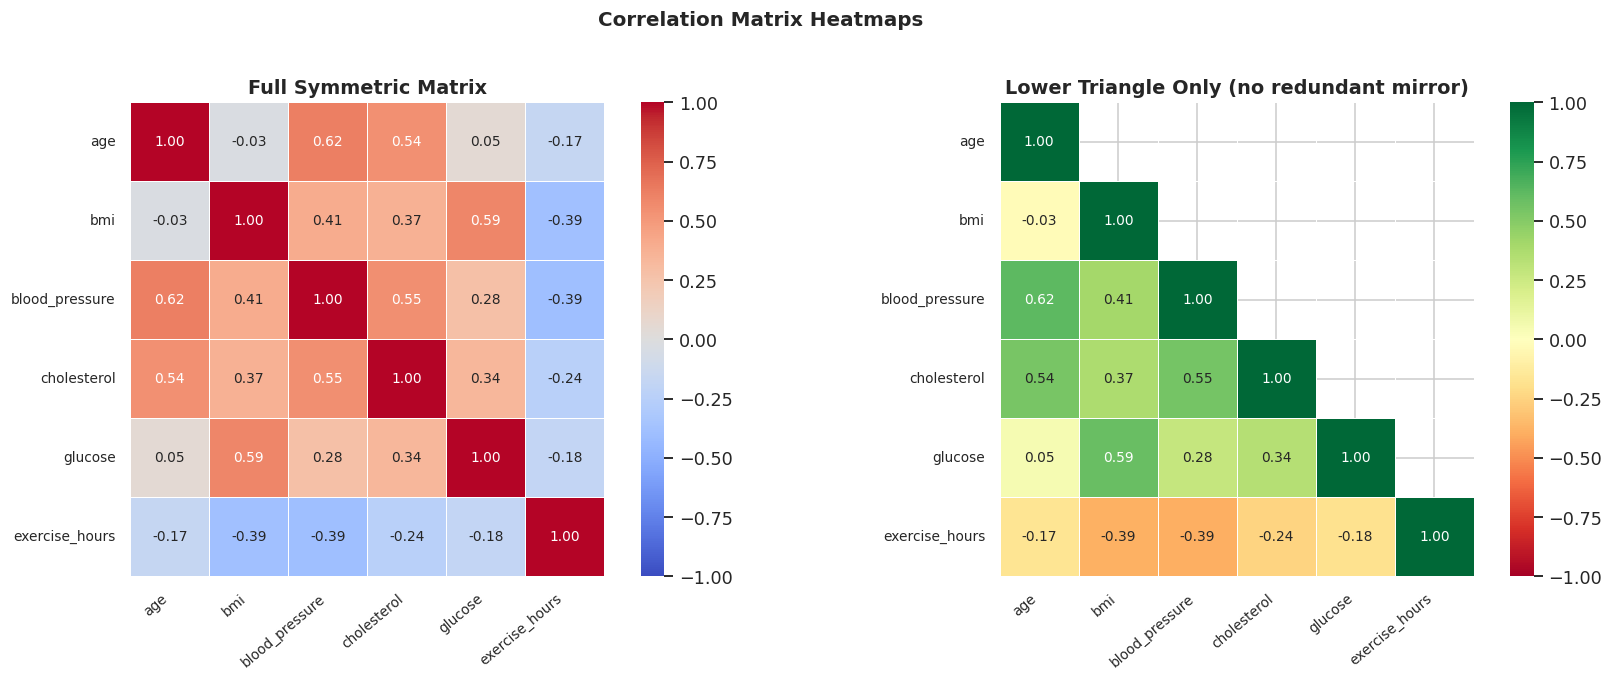


── Strongest correlations (sorted by |r|) ──
     Feature A      Feature B      r
blood_pressure            age  0.621
       glucose            bmi  0.589
   cholesterol blood_pressure  0.547
   cholesterol            age  0.542
blood_pressure            bmi  0.406
exercise_hours blood_pressure -0.393
exercise_hours            bmi -0.388
   cholesterol            bmi  0.368
       glucose    cholesterol  0.339
       glucose blood_pressure  0.275
exercise_hours    cholesterol -0.243
exercise_hours        glucose -0.180
exercise_hours            age -0.169
       glucose            age  0.054
           bmi            age -0.027

📊 Reading the heatmaps:
  Dark red cells = strong positive correlation (both features rise together).
  Dark blue / red in RdYlGn = strong negative (one rises as other falls).
  blood_pressure and cholesterol are strongly correlated with each other
  AND with age — a classic sign of multicollinearity to watch for in regression.
  exercise_hours is negatively 

In [8]:
# ── sns.heatmap — visualise the correlation matrix as a colour grid ────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Correlation Matrix Heatmaps", fontsize=13, fontweight="bold", y=1.02)

# ── Panel Left: Full symmetric matrix ────────────────────────────────────────
sns.heatmap(
    corr_matrix,              # the (6×6) correlation DataFrame
    ax       = axes[0],       # draw into this specific Axes
    annot    = True,          # print r values inside each cell
    fmt      = ".2f",         # format: 2 decimal places
    cmap     = "coolwarm",    # colour map: blue (negative) → white (0) → red (positive)
    vmin     = -1.0,          # pin colour scale minimum to -1
    vmax     =  1.0,          # pin colour scale maximum to +1
    linewidths = 0.5,         # thin white grid lines between cells
    linecolor  = "white",
    square   = True,          # force cells to be square
    annot_kws = {"size": 9}   # annotation font size
)
axes[0].set_title("Full Symmetric Matrix", fontweight="bold")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=40, ha="right", fontsize=9)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0,  fontsize=9)

# ── Panel Right: Upper triangle only (remove redundant mirror half) ───────────
# np.triu returns a mask that is True in the upper-triangle (including diagonal)
# Passing mask=True to heatmap hides those cells — showing only lower triangle
mask_upper = np.triu(np.ones_like(corr_matrix, dtype=bool), k=0)
# k=0 includes diagonal (all 1.0s); use k=1 to show diagonal too
mask_lower_only = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    ax         = axes[1],
    mask       = mask_lower_only,  # hide the UPPER triangle (show lower + diagonal)
    annot      = True,
    fmt        = ".2f",
    cmap       = "RdYlGn",        # red (negative) → yellow (0) → green (positive)
    vmin       = -1.0,
    vmax       =  1.0,
    linewidths = 0.5,
    linecolor  = "white",
    square     = True,
    annot_kws  = {"size": 9}
)
axes[1].set_title("Lower Triangle Only (no redundant mirror)", fontweight="bold")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=40, ha="right", fontsize=9)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0,  fontsize=9)

fig.tight_layout()
plt.show()

# ── Print the strongest correlations ──────────────────────────────────────────
# Unstack the matrix and drop the diagonal (r=1.0) and mirror duplicates
corr_pairs = (
    corr_matrix
    .where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))  # lower tri, no diag
    .stack()
    .reset_index()
)
corr_pairs.columns = ["Feature A", "Feature B", "r"]
corr_pairs = corr_pairs.reindex(corr_pairs["r"].abs().sort_values(ascending=False).index)

print("\n── Strongest correlations (sorted by |r|) ──")
print(corr_pairs.round(3).to_string(index=False))

print("""
📊 Reading the heatmaps:
  Dark red cells = strong positive correlation (both features rise together).
  Dark blue / red in RdYlGn = strong negative (one rises as other falls).
  blood_pressure and cholesterol are strongly correlated with each other
  AND with age — a classic sign of multicollinearity to watch for in regression.
  exercise_hours is negatively correlated with BP and cholesterol — consistent
  with the health science literature.
""")

---
## Section 5 — Pair Plot: All Pairwise Relationships at Once

### 📖 The Logic

A **pair plot** is a grid of scatter plots where every feature is plotted against every other feature. The diagonal (where a feature would be plotted against itself) shows the feature's own distribution instead.

**Why it is the best single EDA plot:** in one call you get:
- The distribution shape of every feature (diagonal)
- Every pairwise relationship (off-diagonal scatter plots)
- Class separation for a categorical variable (via `hue=`)

A pair plot on a 6-feature dataset produces a 6×6 = 36-panel grid — 30 scatter plots + 6 distribution plots. `sns.pairplot()` generates all 36 automatically.

**`sns.pairplot` is a figure-level function** — it returns a `PairGrid` object, not a single `Axes`. Access the underlying Figure with `.fig` and the 2-D array of Axes with `.axes`.

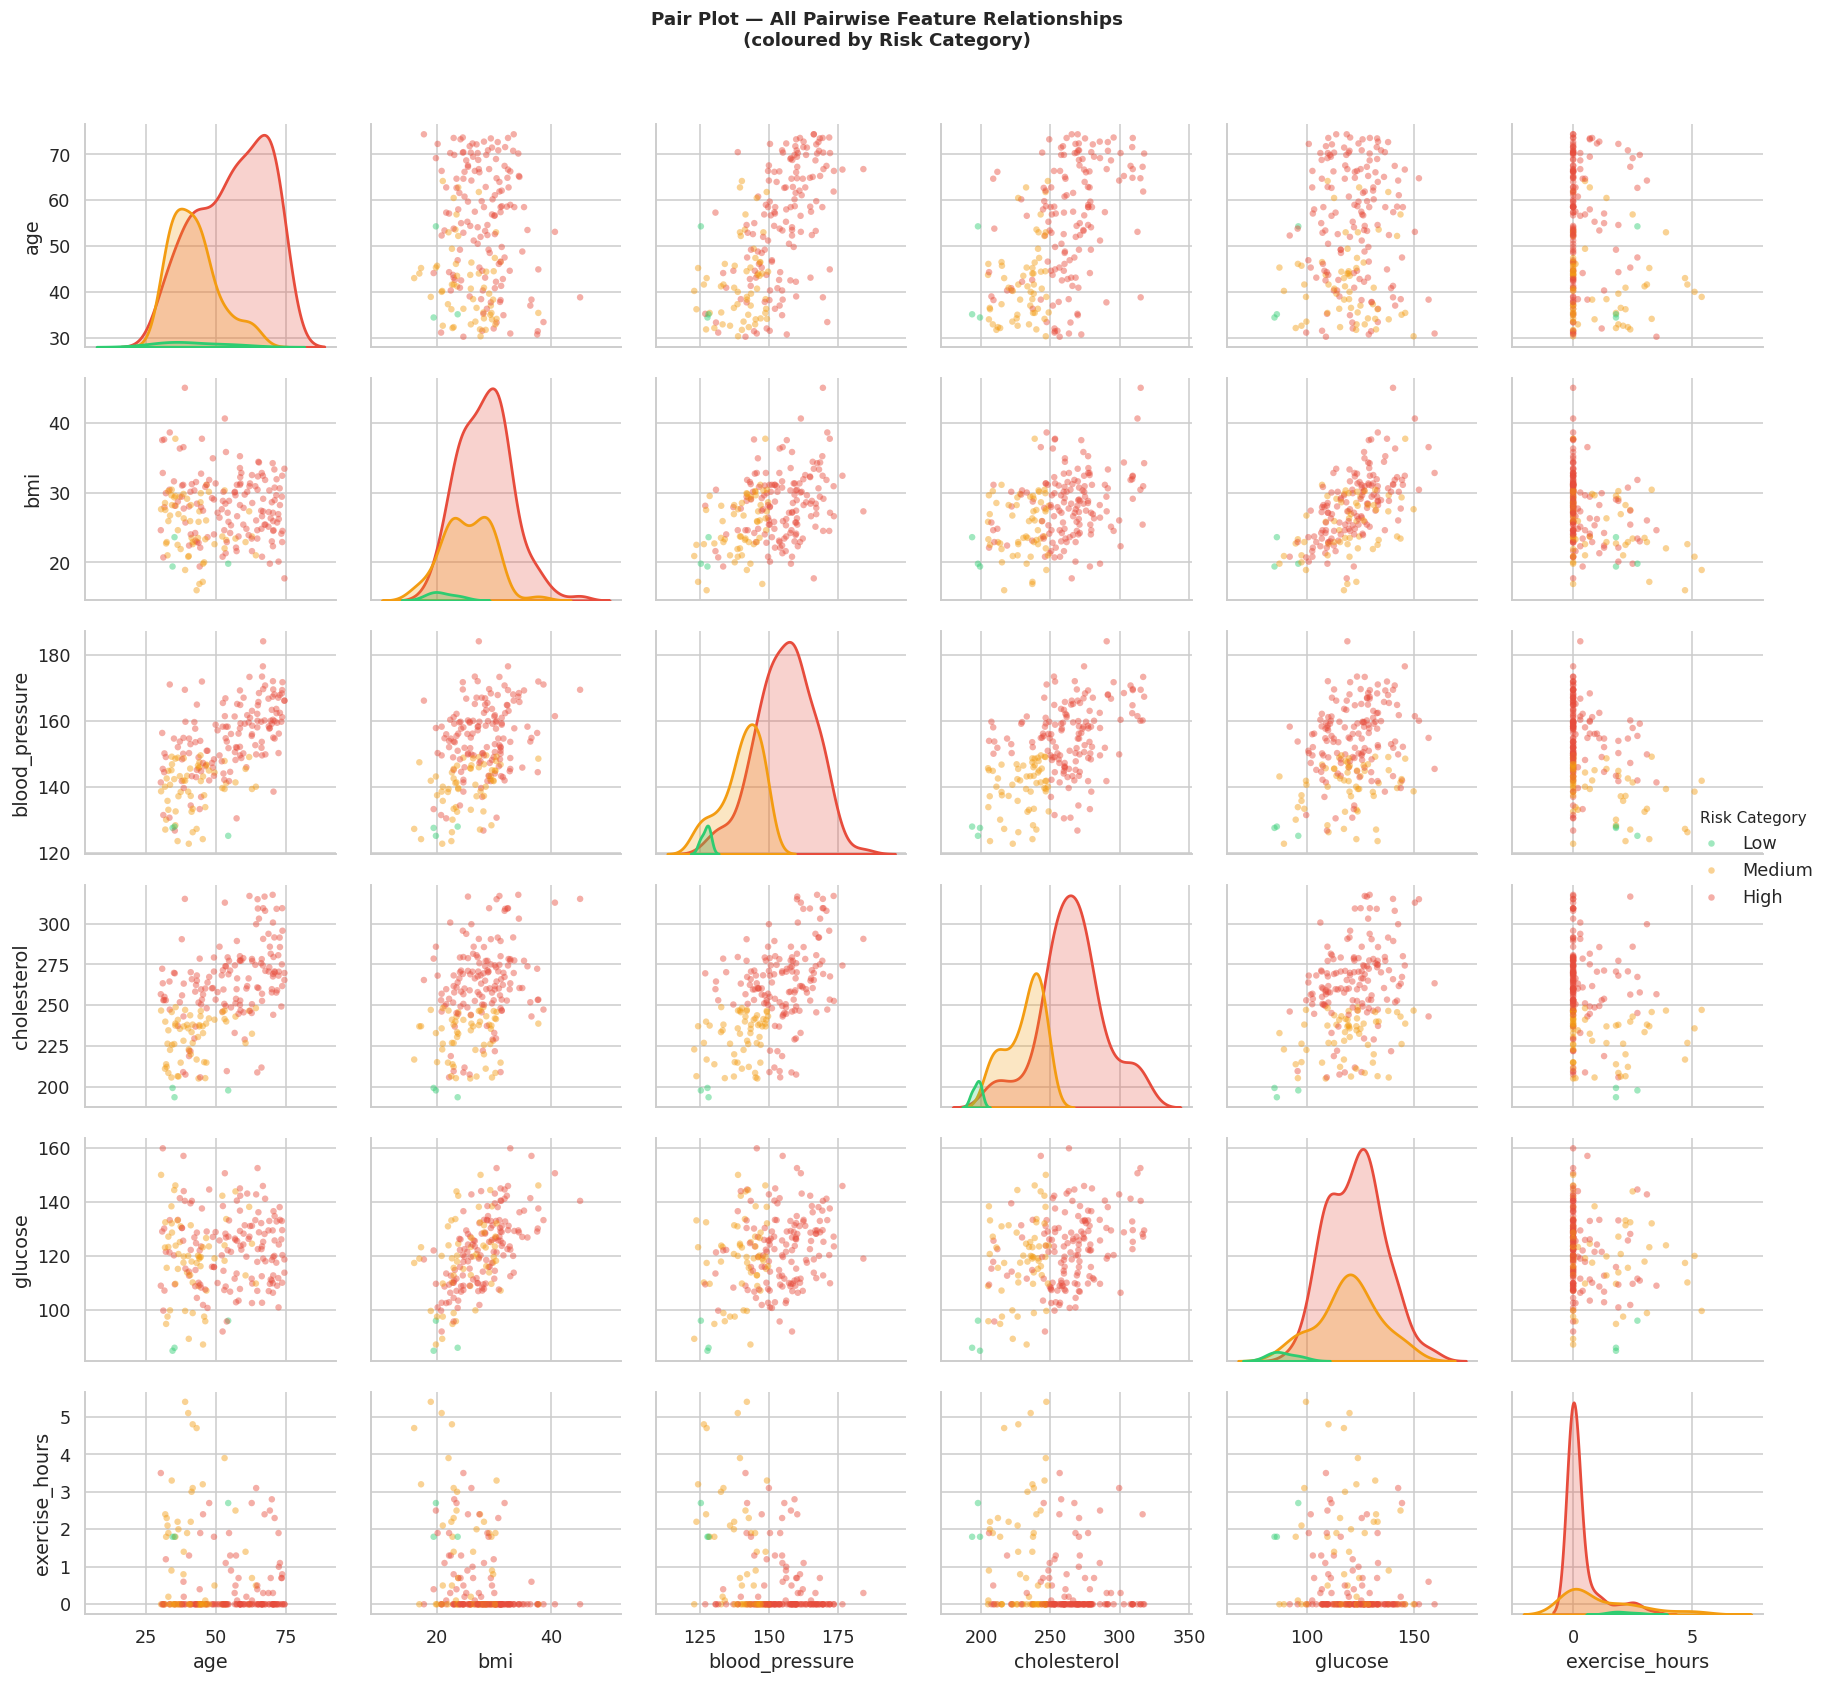


📊 Reading the pair plot:
  Diagonal KDE curves — the three risk groups overlap heavily on 'age' and 'bmi'
  but separate clearly on 'blood_pressure', 'cholesterol', and 'exercise_hours'.
  These are the most discriminative features.

  Off-diagonal scatter plots — blood_pressure vs cholesterol (row 2, col 3)
  shows a clear positive trend with visible group separation: High-risk patients
  (red) cluster in the top-right (high BP and high cholesterol simultaneously).

  exercise_hours vs cholesterol — negative trend visible across all groups,
  consistent with the strong negative r in the heatmap.



In [9]:
# ── sns.pairplot — full pairwise grid coloured by risk category ───────────────
# hue='risk_category' → each risk group gets its own colour throughout the grid
# diag_kind='kde'     → diagonal shows KDE (smooth density curve) instead of histogram
# plot_kws            → kwargs passed to the scatter plot function
# diag_kws            → kwargs passed to the diagonal KDE/hist function

g = sns.pairplot(
    df,
    vars          = numeric_cols,          # only plot numeric columns (exclude risk_category)
    hue           = "risk_category",       # colour by risk group
    hue_order     = ["Low", "Medium", "High"],  # enforce colour order
    palette       = risk_palette,          # our green/orange/red palette
    diag_kind     = "kde",                 # diagonal: KDE distribution curve
    plot_kws      = {"alpha": 0.45,        # semi-transparent scatter points
                     "s": 18,              # smaller dots to reduce overplotting
                     "edgecolors": "none"},# no marker border for cleaner look
    diag_kws      = {"linewidth": 1.8},    # KDE line thickness on diagonal
    corner        = False                  # show full grid (not just lower triangle)
)

# ── Figure-level title — accessed via the .fig attribute ─────────────────────
g.fig.suptitle(
    "Pair Plot — All Pairwise Feature Relationships\n(coloured by Risk Category)",
    fontsize=12, fontweight="bold",
    y=1.02   # push title above the grid
)

# ── Adjust legend position via the figure-level legend handle ─────────────────
g.legend.set_bbox_to_anchor((1.02, 0.5))  # move legend to the right of the grid
g.legend.set_title("Risk Category", prop={"size": 10})

plt.tight_layout()
plt.show()

print("""
📊 Reading the pair plot:
  Diagonal KDE curves — the three risk groups overlap heavily on 'age' and 'bmi'
  but separate clearly on 'blood_pressure', 'cholesterol', and 'exercise_hours'.
  These are the most discriminative features.

  Off-diagonal scatter plots — blood_pressure vs cholesterol (row 2, col 3)
  shows a clear positive trend with visible group separation: High-risk patients
  (red) cluster in the top-right (high BP and high cholesterol simultaneously).

  exercise_hours vs cholesterol — negative trend visible across all groups,
  consistent with the strong negative r in the heatmap.
""")

---
## Section 6 — Violin Plot: The Distribution-Aware Box Plot

### 📖 The Logic

A **violin plot** combines the summary statistics of a box plot with the shape information of a KDE (Kernel Density Estimate). The 'violin' shape shows the full probability density — wider sections indicate more data points near that value.

**Box plot vs Violin plot:**

```
         BOX PLOT                     VIOLIN PLOT
    ┌─────────────┐              ╭──────────────────╮
    │             │             ╭╯                  ╰╮
  ──┤   median    ├──          ╭╯                    ╰╮
    │             │          ──┤   fatter = more data  ├──
    └─────────────┘           ╰╮    near this value   ╭╯
                                ╰╮                  ╭╯
                                 ╰──────────────────╯

  Shows: Q1, Q2, Q3, IQR,       Shows: full distribution shape,
         whiskers, outliers       mode(s), skewness, bimodality
```

**When to prefer violin over box:**
- When you suspect a bimodal or non-symmetric distribution — a box plot would hide this
- When comparing distributions across 3+ categories where shape differences matter
- In publications where a rich visual is appropriate

**When to prefer box over violin:**
- When you specifically need to communicate quartile values
- When n is very small (KDE estimation is unreliable with < 30 points)

/tmp/ipykernel_10588/2946299411.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_10588/2946299411.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


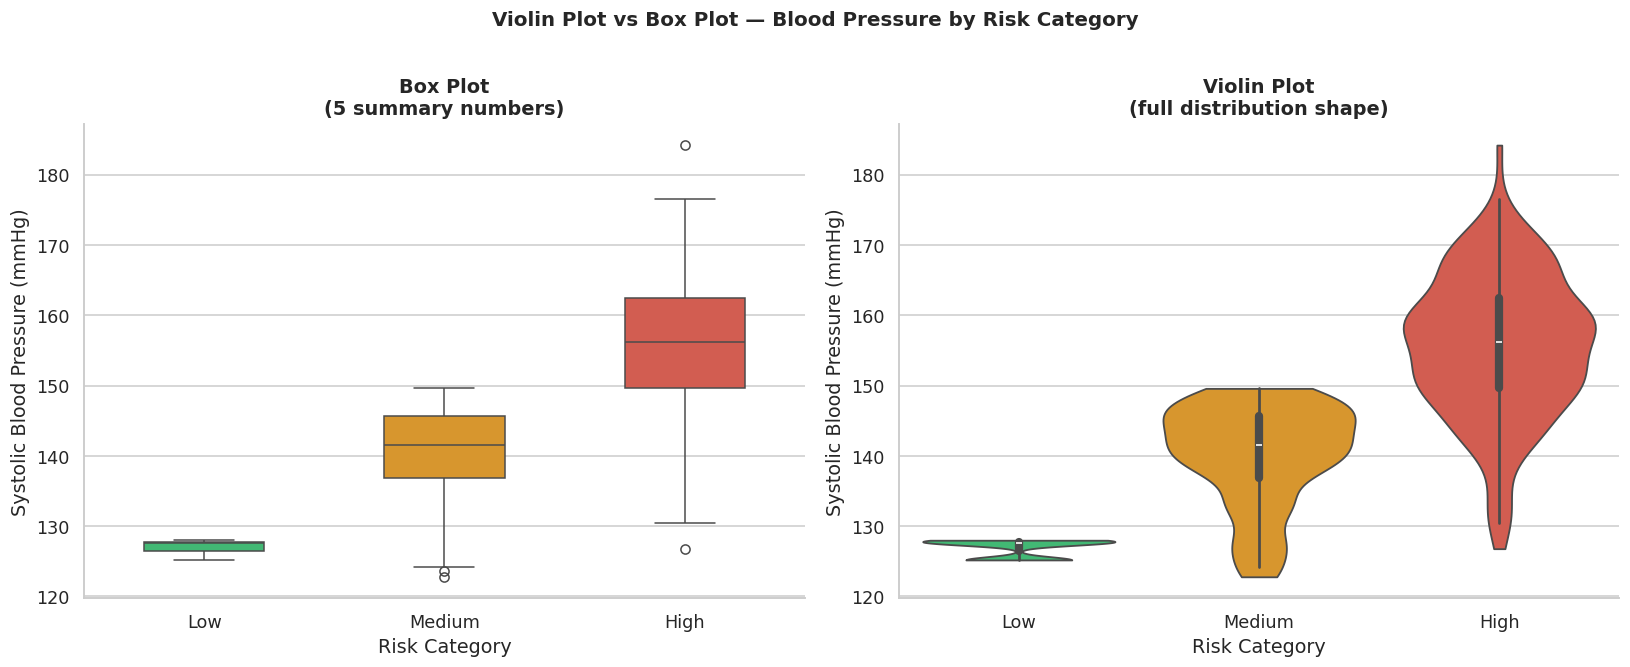


📊 Reading the charts:
  Left  — Box plot: each group's median and IQR are clear. High-risk patients
           have a noticeably higher median BP. A few outliers are visible.
  Right — Violin plot reveals the same pattern but adds shape information:
           the Low-risk distribution is fairly symmetric and narrow;
           the High-risk distribution has a longer upper tail (right-skewed)
           indicating some patients with extremely elevated BP pulling the tail out.
           The inner box shows Q1-Q3 and the median dot.



In [10]:
# ── Violin plots: blood pressure distribution across risk categories ───────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Violin Plot vs Box Plot — Blood Pressure by Risk Category",
             fontsize=13, fontweight="bold", y=1.01)

# ── Panel Left: Box plot (for comparison) ────────────────────────────────────
sns.boxplot(
    data    = df,
    x       = "risk_category",
    y       = "blood_pressure",
    order   = ["Low", "Medium", "High"],
    palette = risk_palette,
    width   = 0.5,
    ax      = axes[0]
)
axes[0].set_title("Box Plot\n(5 summary numbers)", fontweight="bold")
axes[0].set_xlabel("Risk Category")
axes[0].set_ylabel("Systolic Blood Pressure (mmHg)")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# ── Panel Right: Violin plot ──────────────────────────────────────────────────
sns.violinplot(
    data       = df,
    x          = "risk_category",
    y          = "blood_pressure",
    order      = ["Low", "Medium", "High"],
    palette    = risk_palette,
    inner      = "box",        # show a mini box plot inside each violin
                               # alternatives: 'quartile' | 'point' | 'stick' | None
    linewidth  = 1.2,          # violin border thickness
    cut        = 0,            # don't extend violin beyond data range (cut=0)
                               # (default cut=2 extends tails for smoothness)
    bw_method  = 0.3,          # KDE bandwidth: smaller = more detail, larger = smoother
    ax         = axes[1]
)
axes[1].set_title("Violin Plot\n(full distribution shape)", fontweight="bold")
axes[1].set_xlabel("Risk Category")
axes[1].set_ylabel("Systolic Blood Pressure (mmHg)")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.tight_layout()
plt.show()

print("""
📊 Reading the charts:
  Left  — Box plot: each group's median and IQR are clear. High-risk patients
           have a noticeably higher median BP. A few outliers are visible.
  Right — Violin plot reveals the same pattern but adds shape information:
           the Low-risk distribution is fairly symmetric and narrow;
           the High-risk distribution has a longer upper tail (right-skewed)
           indicating some patients with extremely elevated BP pulling the tail out.
           The inner box shows Q1-Q3 and the median dot.
""")

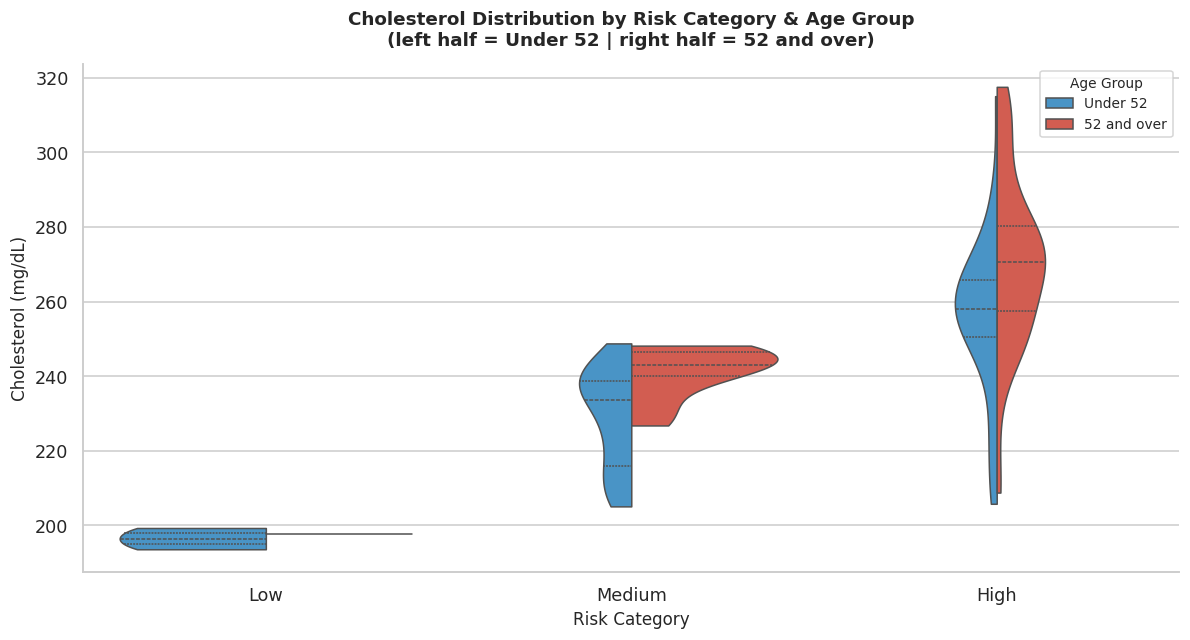


📊 Reading the split violin:
  Each violin is split vertically — the left half (blue) shows patients under 52,
  the right half (red) shows patients 52 and over.
  Within every risk group, older patients (red) have higher and more variable
  cholesterol distributions — the red half is visibly fatter at higher values.
  This plot encodes three variables simultaneously: Risk, Cholesterol, and Age group.



In [11]:
# ── Split violin — show two sub-groups within each category simultaneously ────
# We bin patients into 'Young' (age < 52) and 'Older' (age >= 52)
# then use hue= + split=True to show each age group as one half of each violin

df["age_group"] = np.where(df["age"] < 52, "Under 52", "52 and over")

fig, ax = plt.subplots(figsize=(11, 6))

sns.violinplot(
    data       = df,
    x          = "risk_category",
    y          = "cholesterol",
    hue        = "age_group",             # split by age group
    hue_order  = ["Under 52", "52 and over"],
    split      = True,                    # each hue group gets one half of the violin
    order      = ["Low", "Medium", "High"],
    palette    = {"Under 52": "#3498db", "52 and over": "#e74c3c"},
    inner      = "quartile",              # show thin quartile lines inside
    linewidth  = 1.0,
    cut        = 0,
    ax         = ax
)

ax.set_title("Cholesterol Distribution by Risk Category & Age Group\n"
             "(left half = Under 52 | right half = 52 and over)",
             fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Risk Category", fontsize=11)
ax.set_ylabel("Cholesterol (mg/dL)", fontsize=11)
ax.legend(title="Age Group", fontsize=9, title_fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()

print("""
📊 Reading the split violin:
  Each violin is split vertically — the left half (blue) shows patients under 52,
  the right half (red) shows patients 52 and over.
  Within every risk group, older patients (red) have higher and more variable
  cholesterol distributions — the red half is visibly fatter at higher values.
  This plot encodes three variables simultaneously: Risk, Cholesterol, and Age group.
""")

---
## Section 7 — Seaborn Themes and Palettes

### 📖 The Logic

Seaborn has five built-in style themes and three types of colour palettes. Choosing the right combination significantly affects readability and visual clarity.

**Style themes** (set with `sns.set_style()`):

| Theme | Best for |
|-------|----------|
| `whitegrid` | Most plots — clean with reference grid |
| `darkgrid` | Dense scatter plots — grid stands out |
| `white` | Minimalist — no grid |
| `dark` | High-contrast overlays |
| `ticks` | Publication figures — minimal ticks only |

**Colour palette types:**

| Type | Example names | Use for |
|------|--------------|--------|
| **Qualitative** | `muted`, `deep`, `pastel`, `Set2` | Unordered categorical groups |
| **Sequential** | `Blues`, `YlOrRd`, `viridis` | Ordered numeric data (low → high) |
| **Diverging** | `coolwarm`, `RdYlGn`, `bwr` | Data centred at a meaningful zero (correlations, residuals) |

/tmp/ipykernel_10588/3801223870.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_10588/3801223870.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_10588/3801223870.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_10588/3801223870.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


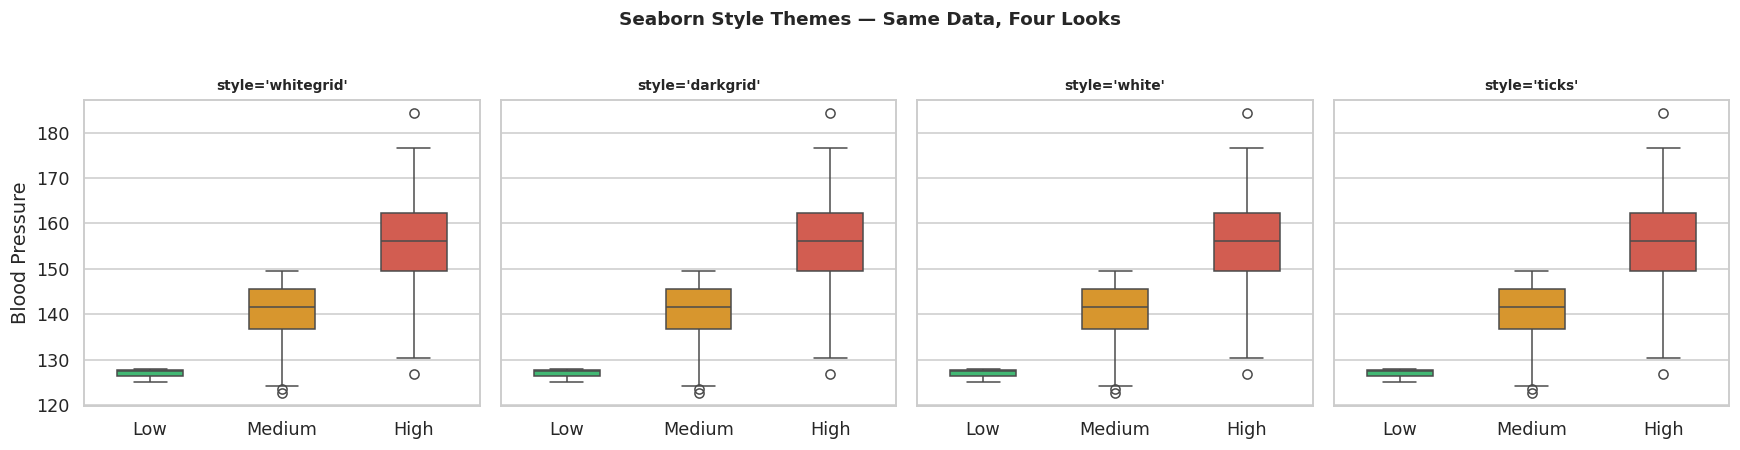

In [12]:
# ── Side-by-side style comparison ─────────────────────────────────────────────
styles   = ["whitegrid", "darkgrid", "white", "ticks"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
fig.suptitle("Seaborn Style Themes — Same Data, Four Looks",
             fontsize=12, fontweight="bold", y=1.02)

for ax, style in zip(axes, styles):
    with sns.axes_style(style):            # context manager — applies style temporarily
        # Draw a fresh ax inside the context so the style applies
        sns.boxplot(
            data    = df,
            x       = "risk_category",
            y       = "blood_pressure",
            order   = ["Low", "Medium", "High"],
            palette = risk_palette,
            width   = 0.5,
            ax      = ax
        )
    ax.set_title(f"style='{style}'", fontweight="bold", fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("Blood Pressure" if ax == axes[0] else "")

fig.tight_layout()
plt.show()

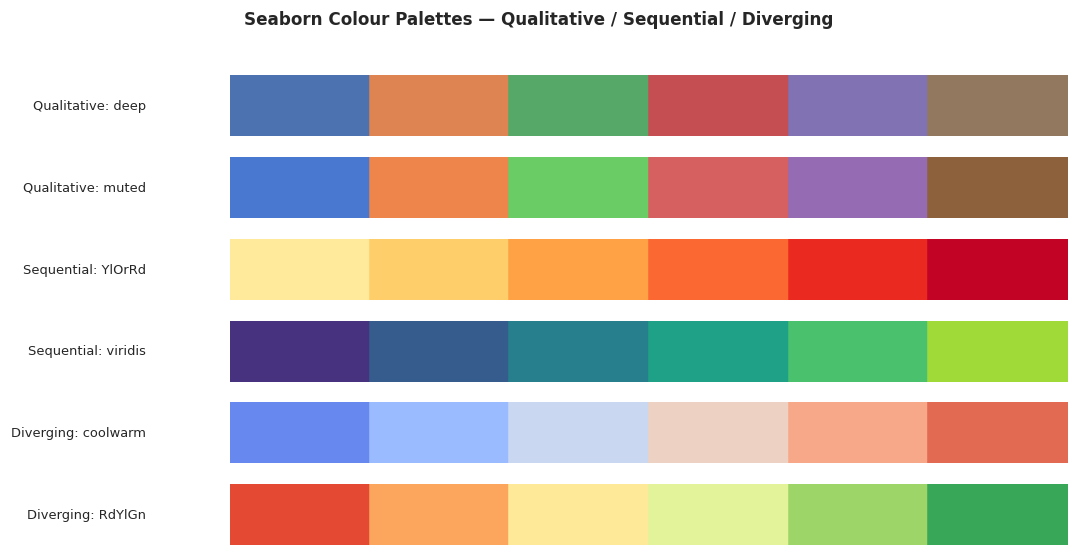

In [13]:
# ── Colour palette showcase ───────────────────────────────────────────────────
palettes = {
    "Qualitative: deep"    : sns.color_palette("deep",    n_colors=6),
    "Qualitative: muted"   : sns.color_palette("muted",   n_colors=6),
    "Sequential: YlOrRd"   : sns.color_palette("YlOrRd",  n_colors=6),
    "Sequential: viridis"  : sns.color_palette("viridis", n_colors=6),
    "Diverging: coolwarm"  : sns.color_palette("coolwarm", n_colors=6),
    "Diverging: RdYlGn"    : sns.color_palette("RdYlGn",  n_colors=6),
}

fig, axes = plt.subplots(len(palettes), 1, figsize=(10, 5))
fig.suptitle("Seaborn Colour Palettes — Qualitative / Sequential / Diverging",
             fontsize=11, fontweight="bold", y=1.01)

for ax, (name, colours) in zip(axes, palettes.items()):
    for i, colour in enumerate(colours):
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=colour))  # coloured rectangle
    ax.set_xlim(0, 6)
    ax.set_ylim(0, 1)
    ax.axis("off")                              # hide axes — this is a colour swatch
    ax.text(-0.1, 0.5, name, va="center", ha="right", fontsize=8.5,
            transform=ax.transAxes)

fig.tight_layout()
plt.show()

---
## Section 8 — Combined EDA Dashboard

### 📖 The Logic

In practice, your EDA for a new dataset involves running several Seaborn plots in sequence. This section builds a single 6-panel dashboard — the kind you would produce at the start of any ML project — using Matplotlib's `GridSpec` for layout and Seaborn for the content.

/tmp/ipykernel_10588/2073503575.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


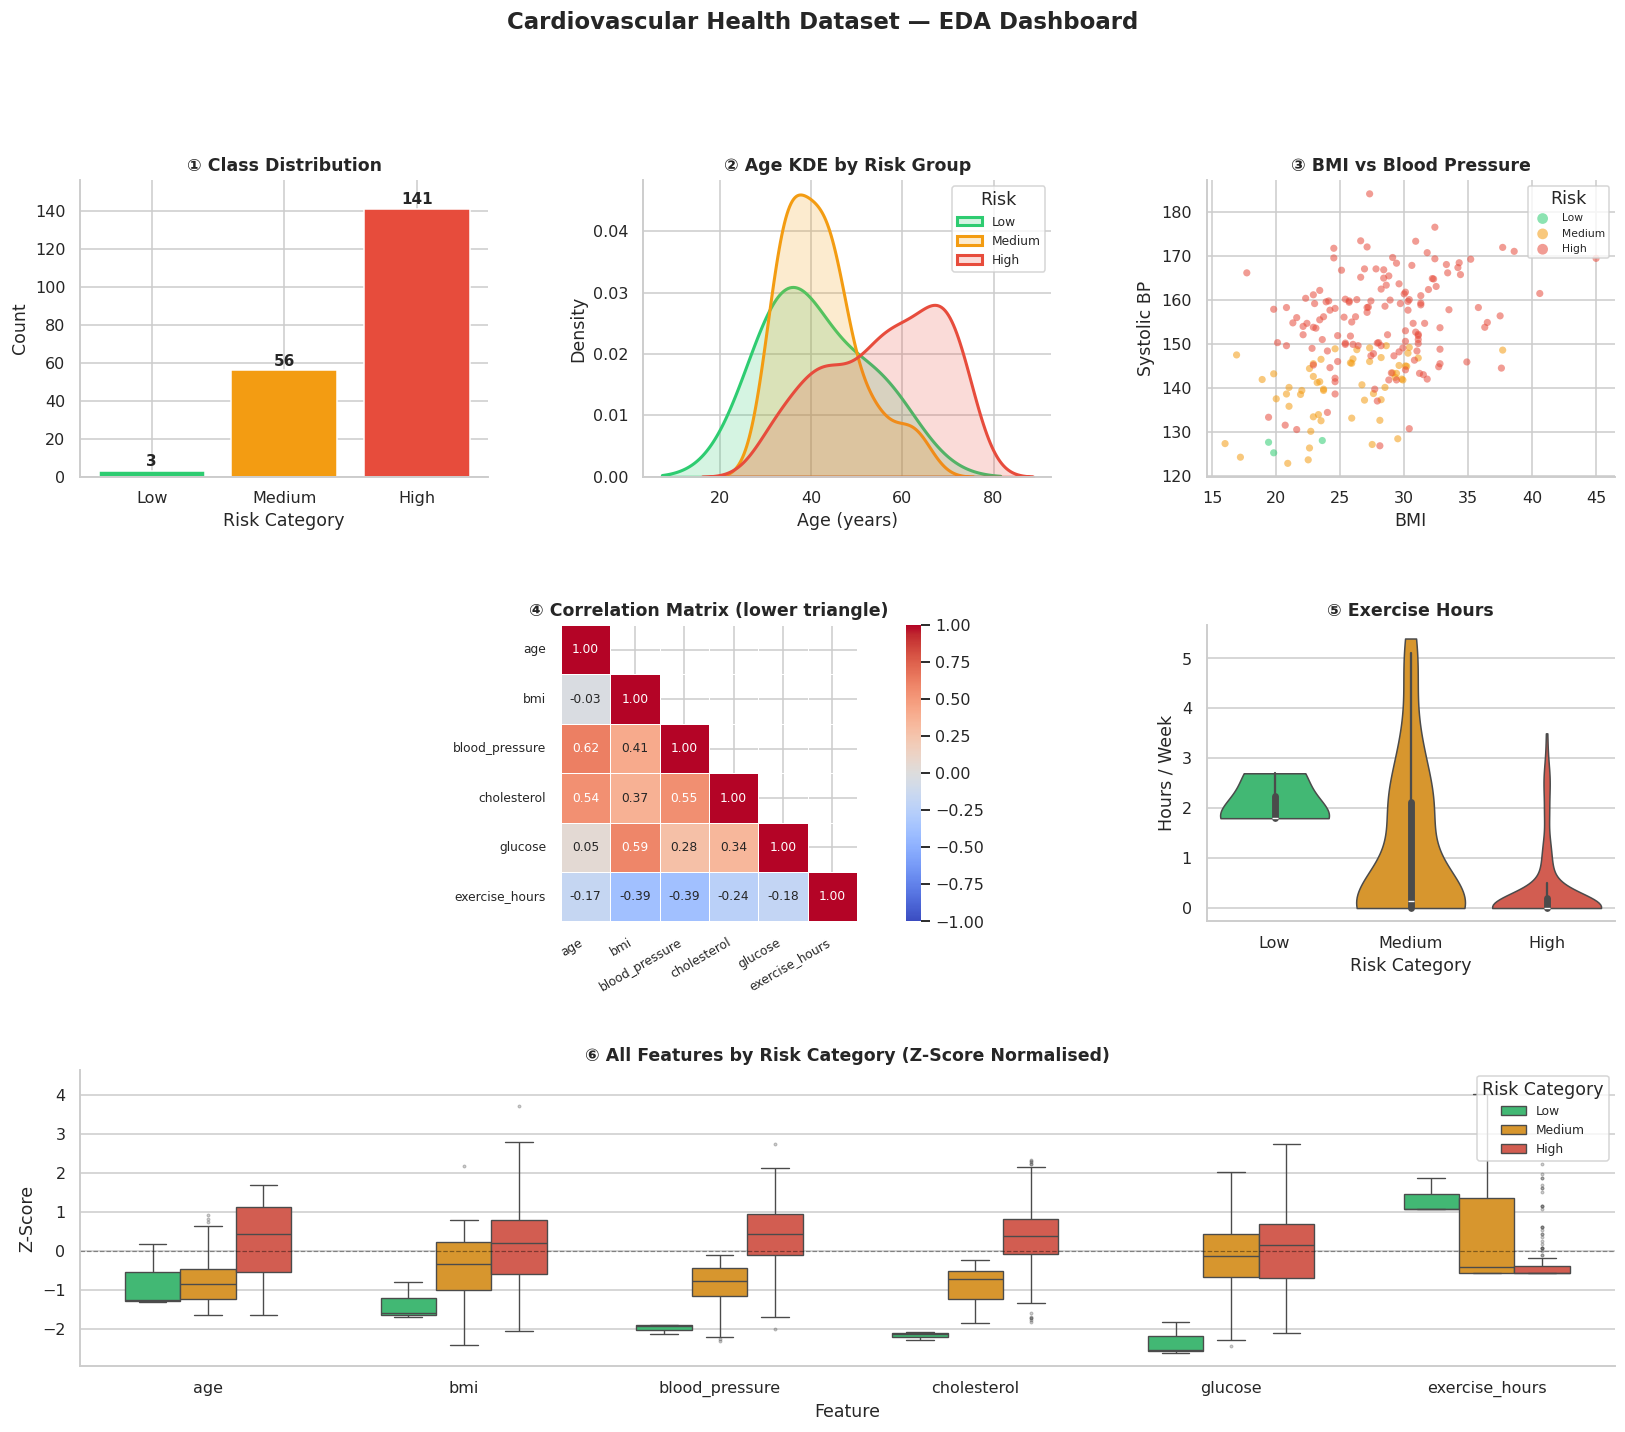


📊 Reading the dashboard:
  ① ~40% Low, ~35% Medium, ~25% High — a slightly imbalanced dataset.
  ② All three risk groups span similar ages — age alone is a poor discriminator.
  ③ High-risk patients (red) cluster top-right — high BMI + high BP together.
  ④ Strong positive correlations: BP↔Cholesterol, Age↔Cholesterol, Age↔BP.
     Strong negative: exercise_hours↔BP and exercise_hours↔cholesterol.
  ⑤ High-risk patients exercise the least — clear separation from Low-risk.
  ⑥ Panel 6 summarises everything: High-risk (red) consistently above mean
     on BP, Cholesterol, Glucose; consistently below mean on exercise_hours.
     This is the feature profile of a high-risk patient in one chart.



In [14]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=0.95)

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Cardiovascular Health Dataset — EDA Dashboard",
             fontsize=15, fontweight="bold", y=0.99)

gs = gridspec.GridSpec(
    3, 3,
    figure=fig,
    hspace=0.50,
    wspace=0.38
)

ax1 = fig.add_subplot(gs[0, 0])     # top-left
ax2 = fig.add_subplot(gs[0, 1])     # top-centre
ax3 = fig.add_subplot(gs[0, 2])     # top-right
ax4 = fig.add_subplot(gs[1, :2])    # middle spans cols 0–1
ax5 = fig.add_subplot(gs[1, 2])     # middle col 2
ax6 = fig.add_subplot(gs[2, :])     # bottom spans all 3 cols

# ════ Panel 1: Risk category counts — bar chart ══════════════════════════════
risk_counts = df["risk_category"].value_counts().reindex(["Low","Medium","High"])
ax1.bar(
    risk_counts.index, risk_counts.values,
    color=[risk_palette[r] for r in risk_counts.index],
    edgecolor="white"
)
for i, (cat, cnt) in enumerate(risk_counts.items()):
    ax1.text(i, cnt + 1, str(cnt), ha="center", va="bottom",
             fontsize=10, fontweight="bold")
ax1.set_title("① Class Distribution", fontweight="bold")
ax1.set_xlabel("Risk Category")
ax1.set_ylabel("Count")
ax1.set_ylim(0, risk_counts.max() + 15)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# ════ Panel 2: Age distribution by risk — KDE ════════════════════════════════
for risk_lvl, colour in risk_palette.items():
    subset = df.loc[df["risk_category"] == risk_lvl, "age"]
    sns.kdeplot(
        subset, ax=ax2, color=colour, linewidth=2, fill=True, alpha=0.20,
        label=risk_lvl
    )
ax2.set_title("② Age KDE by Risk Group", fontweight="bold")
ax2.set_xlabel("Age (years)")
ax2.set_ylabel("Density")
ax2.legend(title="Risk", fontsize=8)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# ════ Panel 3: BMI vs Blood Pressure scatter — coloured by risk ═══════════════
for risk_lvl, colour in risk_palette.items():
    sub = df[df["risk_category"] == risk_lvl]
    ax3.scatter(sub["bmi"], sub["blood_pressure"],
                color=colour, s=22, alpha=0.55, edgecolors="none",
                label=risk_lvl)
ax3.set_title("③ BMI vs Blood Pressure", fontweight="bold")
ax3.set_xlabel("BMI")
ax3.set_ylabel("Systolic BP")
ax3.legend(title="Risk", fontsize=7, markerscale=1.5)
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)

# ════ Panel 4: Heatmap — correlation matrix ════════════════════════════════
sns.heatmap(
    df[numeric_cols].corr().round(2),
    ax         = ax4,
    annot      = True,
    fmt        = ".2f",
    cmap       = "coolwarm",
    vmin=-1, vmax=1,
    linewidths = 0.5,
    linecolor  = "white",
    square     = True,
    annot_kws  = {"size": 8},
    mask       = np.triu(np.ones((6, 6), dtype=bool), k=1)   # hide upper triangle
)
ax4.set_title("④ Correlation Matrix (lower triangle)", fontweight="bold")
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=30, ha="right", fontsize=8)
ax4.set_yticklabels(ax4.get_yticklabels(), rotation=0, fontsize=8)

# ════ Panel 5: Violin — exercise hours by risk ════════════════════════════════
sns.violinplot(
    data     = df,
    x        = "risk_category",
    y        = "exercise_hours",
    order    = ["Low", "Medium", "High"],
    palette  = risk_palette,
    inner    = "box",
    cut      = 0,
    linewidth= 1.0,
    ax       = ax5
)
ax5.set_title("⑤ Exercise Hours", fontweight="bold")
ax5.set_xlabel("Risk Category")
ax5.set_ylabel("Hours / Week")
ax5.spines["top"].set_visible(False)
ax5.spines["right"].set_visible(False)

# ════ Panel 6: Grouped box plots — all features by risk ═══════════════════════
df_z2 = df[numeric_cols].apply(lambda col: (col - col.mean()) / col.std())
df_z2["risk_category"] = df["risk_category"]
df_z2_long = df_z2.melt(id_vars="risk_category",
                         var_name="Feature", value_name="Z-Score")

sns.boxplot(
    data     = df_z2_long,
    x        = "Feature",
    y        = "Z-Score",
    hue      = "risk_category",
    hue_order= ["Low", "Medium", "High"],
    palette  = risk_palette,
    width    = 0.65,
    linewidth= 0.9,
    flierprops = dict(marker=".", markersize=3, alpha=0.4),
    ax       = ax6
)
ax6.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax6.set_title("⑥ All Features by Risk Category (Z-Score Normalised)",
              fontweight="bold")
ax6.set_xlabel("Feature")
ax6.set_ylabel("Z-Score")
ax6.legend(title="Risk Category", fontsize=8, loc="upper right")
ax6.spines["top"].set_visible(False)
ax6.spines["right"].set_visible(False)

plt.savefig("/tmp/nb9_dashboard.png", dpi=120, bbox_inches="tight",
            facecolor="white")
plt.show()

print("""
📊 Reading the dashboard:
  ① ~40% Low, ~35% Medium, ~25% High — a slightly imbalanced dataset.
  ② All three risk groups span similar ages — age alone is a poor discriminator.
  ③ High-risk patients (red) cluster top-right — high BMI + high BP together.
  ④ Strong positive correlations: BP↔Cholesterol, Age↔Cholesterol, Age↔BP.
     Strong negative: exercise_hours↔BP and exercise_hours↔cholesterol.
  ⑤ High-risk patients exercise the least — clear separation from Low-risk.
  ⑥ Panel 6 summarises everything: High-risk (red) consistently above mean
     on BP, Cholesterol, Glucose; consistently below mean on exercise_hours.
     This is the feature profile of a high-risk patient in one chart.
""")

---
## ✅ Notebook Summary & Key Takeaways

| Concept | Core rule | Gotcha to remember |
|---------|-----------|--------------------|
| **Seaborn layers on Matplotlib** | Every Seaborn plot IS a Matplotlib plot | After `sns.boxplot(ax=ax)`, use `ax.set_*()` for all further customisation |
| **Axes-level vs Figure-level** | Axes-level: pass `ax=ax`. Figure-level: returns a Grid object | `sns.pairplot` returns a `PairGrid` — access `.fig` and `.axes` |
| **Box plot** | Summarises Q1, median, Q3, whiskers (1.5×IQR), outliers | Outliers are points beyond `Q1 - 1.5×IQR` or `Q3 + 1.5×IQR` |
| **Correlation coefficient r** | Ranges from -1 to +1; diagonal is always 1.0; matrix is symmetric | Measures LINEAR relationship only — non-linear correlations will read as low r |
| **Heatmap mask** | `np.triu(np.ones(...), k=1)` hides upper triangle | `k=0` includes diagonal; `k=1` excludes it |
| **Pairplot** | One call generates all n² pairwise plots + diagonal distributions | Use `vars=` to limit to numeric columns; `hue=` for categorical colouring |
| **Violin plot** | Shows full KDE distribution shape, not just 5 numbers | Use `inner='box'` to embed summary stats inside; `cut=0` to not extend beyond data |
| **Split violin** | `split=True` + `hue=` shows two sub-groups as left/right halves | Requires exactly 2 hue groups |
| **`sns.set_theme()`** | Sets style + palette + font scale globally | Call once at the top of your notebook |
| **Diverging palette** | Use for data centred at 0 (correlations, residuals) | `coolwarm` and `RdYlGn` are the most readable choices |

---
